In [1]:
import numpy as np
import pandas as pd
# land_df = pd.read_csv('data/county_landmass.csv')
# pop_df = pd.read_csv('data/uscounties.csv')

data_dir = '/home/andrew/abm_violence/data/'
ffl_df = pd.read_csv(f'{data_dir}ffl_list.txt', sep='\t')
zips_loc = pd.read_csv(f'{data_dir}2013_us_zips.csv')
city_df = pd.read_csv(f'{data_dir}uscities.csv')
mj_shootings = pd.read_csv(f"{data_dir}mother_jones.csv")

#function to replace non-alphanumeric characters with underscores and convert to uppercase
def clean_string(s):
    return ''.join(['_' if not c.isalnum() else c for c in s.strip()]).upper()
import json
with open(f'{data_dir}state_acronym.json') as f:
    state_acr = json.load(f)
state_acr = {k: clean_string(v) for k, v in state_acr.items()}
ffl_df['PREMISE_STATE_ACR'] = ffl_df['PREMISE_STATE'].copy()
ffl_df['PREMISE_STATE'] = ffl_df['PREMISE_STATE_ACR'].map(state_acr)
ffl_df['PREMISE_CITY'] = ffl_df['PREMISE_CITY'].apply(clean_string)

city_df['city_upper'] = city_df['city_ascii'].apply(clean_string)
city_df['state_upper'] = city_df['state_name'].apply(clean_string)

In [2]:
major_licenses = ffl_df[ffl_df["LIC_TYPE"].isin([1, 2, 7])].reset_index(drop=True)
premise_loc = pd.merge(major_licenses[['PREMISE_ZIP_CODE']], zips_loc, left_on='PREMISE_ZIP_CODE', right_on='ZIP', how='left')
mail_loc = pd.merge(major_licenses[['MAIL_ZIP_CODE']], zips_loc, left_on='MAIL_ZIP_CODE', right_on='ZIP', how='left')
city_loc = pd.merge(major_licenses[['PREMISE_CITY', 'PREMISE_STATE']], 
                    city_df[['city_upper', 'state_upper', 'lat', 'lng']].drop_duplicates(['city_upper', 'state_upper']),
                    left_on=['PREMISE_CITY', 'PREMISE_STATE'], right_on=['city_upper', 'state_upper'], how='left')
aggr_loc = premise_loc.copy()
aggr_loc.loc[aggr_loc['LAT'].isna(), ['LAT', 'LNG']] = mail_loc[aggr_loc['LAT'].isna()][['LAT', 'LNG']].values
aggr_loc.loc[aggr_loc['LAT'].isna(), ['LAT', 'LNG']]  = city_loc[aggr_loc['LAT'].isna()][['lat', 'lng']].values
major_licenses[['LAT', 'LNG']] = aggr_loc[['LAT', 'LNG']]
major_licenses.dropna(subset=['LAT', 'LNG'], inplace=True)

In [3]:
#Calc lat, lng for all shooting events
mj_shootings['state'] = [clean_string(x.split(',')[1]) for x in mj_shootings['location']]
mj_shootings['city'] = [clean_string(x.split(',')[0]) for x in mj_shootings['location']]
mj_shootings = mj_shootings.drop(columns=['case', 'location.1', 'age_of_shooter', 'prior_signs_mental_health_issues', 'mental_health_sources', 
                                        'mental_health_details', 'weapons_obtained_legally', 'where_obtained',
                                        'weapon_type', 'weapon_details', 'race', 'gender', 'sources',
                                        'sources_additional_age'])
mj_loc = mj_shootings[['city', 'state']].merge(city_df[['city_upper', 'state_upper', 'lat', 'lng']], 
                                               left_on=['city', 'state'], right_on=['city_upper', 'state_upper'], how='left')
mj_shootings[['lat', 'lng']] = mj_loc[['lat', 'lng']]
mj_shootings[['latitude', 'longitude']] = mj_shootings[['latitude', 'longitude']].replace('-', np.nan).astype(float)
mj_shootings.loc[mj_shootings['latitude'].isna(), ['latitude', 'longitude']] = mj_shootings.loc[mj_shootings['latitude'].isna(), ['lat', 'lng']].values
mj_shootings.loc[mj_shootings['city'] == 'HEDINGHAM', ['latitude', 'longitude']] = [35.811023, -78.544826] #hate this city

In [4]:
city_df = pd.read_csv(f'{data_dir}/processed/city_population_density.csv')

In [5]:
def lat_long_to_spherical_vector(lat, lon):
    R = 3958.8
    # take in lat/lon as vectors
    theta = lon
    theta = np.where(theta<180, 180 + (180 -(-lon)), theta)
    phi = (lat - 90) * -1
    x = R*np.sin(np.deg2rad(phi))*np.cos(np.deg2rad(theta))
    y = R*np.sin(np.deg2rad(phi))*np.sin(np.deg2rad(theta))
    z = R*np.cos(np.deg2rad(phi))
    return x,y,z
for df in [major_licenses, mj_shootings]:
    df['x'], df['y'], df['z'] = lat_long_to_spherical_vector(df['LAT' if 'LAT' in df.columns else 'latitude'], 
                                                             df['LNG' if 'LNG' in df.columns else 'longitude'])
city_df['x'], city_df['y'], city_df['z'] = lat_long_to_spherical_vector(city_df['lat'], city_df['lng'])

In [6]:
from sklearn.neighbors import BallTree
def find_nearby_pairs(df1, df2, distance_threshold):
    ball_tree = BallTree(df2[['x', 'y', 'z']].values, leaf_size=2)
    neighbors = ball_tree.query_radius(df1[['x', 'y', 'z']].values, r=distance_threshold)
    return neighbors


ffl_radius = 25 #miles
neighbors = find_nearby_pairs(mj_shootings, major_licenses, ffl_radius)
mj_neighbor_counts = [len(n) for n in neighbors]
mj_shootings['ffl_within_25_miles'] = mj_neighbor_counts
mj_shootings['ffl_density'] = mj_shootings['ffl_within_25_miles'] / (3.14*25*25)

neighbors = find_nearby_pairs(city_df, major_licenses, ffl_radius)
city_neighbor_counts = [len(n) for n in neighbors]
city_df['ffl_within_25_miles'] = city_neighbor_counts
city_df['ffl_density'] = city_df['ffl_within_25_miles'] / (3.14*25*25)

In [29]:
def find_closest(df1, df2):
    ball_tree = BallTree(df2[['x', 'y', 'z']].values, leaf_size=2)
    neighbors = ball_tree.query(df1[['x', 'y', 'z']].values, k=1)
    return neighbors
neighbor_county_dist, neighbor_county_rows = find_closest(mj_shootings, city_df)
shootings_df = pd.concat([mj_shootings.reset_index(drop=True), 
                          city_df.iloc[neighbor_county_rows.flatten()].reset_index(drop=True).add_prefix('county_')], axis=1)

In [30]:
# event_df
def year_to_decade(year):
    #round to nearest decade, minimum 1990
    return max((year % 10 >= 5) * 10 + (year // 10) * 10, 1990)

In [31]:
# shootings_df['decade'] = (shootings_df['year'] // 10) * 10
# shootings_df['decade'] = shootings_df['decade'].apply(lambda x: x if x >= 1990 else 1990)
shootings_df['decade'] = shootings_df['year'].apply(year_to_decade)

In [32]:
decade_population_cols = {
    1990: shootings_df['county_population_1990'],
    2000: shootings_df['county_population_2000'],
    2010: shootings_df['county_population_2010'],
    2020: shootings_df['county_population_2020']
}
decade_density_cols = {
    1990: shootings_df['county_CL8AA1990_density'],
    2000: shootings_df['county_CL8AA2000_density'],
    2010: shootings_df['county_CL8AA2010_density'],
    2020: shootings_df['county_CL8AA2020_density']
}
shootings_df['event_population'] = shootings_df.apply(lambda x: decade_population_cols[x['decade']][x.name], axis=1)
shootings_df['event_density'] = shootings_df.apply(lambda x: decade_density_cols[x['decade']][x.name], axis=1)

In [34]:
event_df = shootings_df[['location', 'year', 'fatalities', 'state', 'city', 'event_population', 'event_density', 'ffl_density', 'county_GISJOIN']].copy()
event_df.rename(columns={
    'county_GISJOIN' : 'GISID',
    'event_population': 'population',
    'event_density': 'population_density'
}, inplace=True)
event_df.to_csv(f"{data_dir}/processed/event_data.csv", index=False)

In [35]:
city_data_df = city_df[['GISJOIN', 'STATE', 'COUNTY', 'population_1990', 'population_2000', 'population_2010', 'population_2020',
                   'CL8AA1990_density', 'CL8AA2000_density', 'CL8AA2010_density', 'CL8AA2020_density',
                   'ffl_density']].copy()
city_data_df.rename(columns={
    'GISJOIN': 'GISID',
    'STATE': 'state',
    'COUNTY': 'county',
    'CL8AA1990_density': 'population_density_1990',
    'CL8AA2000_density': 'population_density_2000',
    'CL8AA2010_density': 'population_density_2010',
    'CL8AA2020_density': 'population_density_2020'
}, inplace=True)
city_data_df.to_csv(f"{data_dir}/processed/city_df.csv", index=False)

In [36]:


event_df['decade'] = event_df['year'].apply(year_to_decade)

In [37]:
from gvabm.param_distr import CityParams, EventOutcome
city_data = {}
for i, row in event_df.iterrows():
    c = (row.GISID, int(row.decade))
    if c not in city_data:
        city_data[c] = {'events': []}
    city_data[c]['params'] = CityParams(row.year, row.population, row.population_density, row.ffl_density*3.14*25*25, row.ffl_density)
    city_data[c]['events'].append(EventOutcome(row.year, row.fatalities, -1, -1, row.population, row.population_density))

In [38]:
for i, row in city_data_df.iterrows():
    location_id = row.GISID
    for year, pop_col, dens_col in [
        (1990, 'population_1990', 'population_density_1990'),
        (2000, 'population_2000', 'population_density_2000'),
        (2010, 'population_2010', 'population_density_2010'),
        (2020, 'population_2020', 'population_density_2020')
    ]:
        c = (location_id, year)
        if c not in city_data:
            city_data[c] = {'events': []}
            city_data[c]['params'] = CityParams(year, row[pop_col], row[dens_col], row.ffl_density*3.14*25*25, row.ffl_density)
        city_data[c]['name'] = (row.state, row.county)
def hasna(p):
    return any(np.isnan(x) for x in p)
city_data = {k: v for k, v in city_data.items() if not hasna(v['params'])}

In [39]:
el = [v for k, v in city_data.items()]
np.argmax([len(el_i['events']) for el_i in el])
el[np.argmax([len(el_i['events']) for el_i in el])]

{'events': [EventOutcome(year=2022, fatalities=5, injured=-1, total_victims=-1, population=406907.51, population_density=1142.554057737293),
  EventOutcome(year=2015, fatalities=3, injured=-1, total_victims=-1, population=406907.51, population_density=1142.554057737293),
  EventOutcome(year=2015, fatalities=3, injured=-1, total_victims=-1, population=406907.51, population_density=1142.554057737293)],
 'params': CityParams(year=2015, population=406907.51, population_density=1142.554057737293, arm_count=255.99999999999997, arm_density=0.13044585987261145),
 'name': ('Colorado', 'El Paso County')}

In [40]:
city_data_l = list(city_data.items())

import random
random.seed(42)
np.random.seed(42)

def softmax(x):
    return np.exp(x) / (1 + np.exp(x))

population_vals = np.array([e[1]['params'][0] for e in city_data_l])
p_weighting = lambda x: 2*(softmax(((x/2e6)))-0.5)
p_weights = np.array([p_weighting(x) for x in population_vals])
had_event = np.array([len(city_data['events']) > 0 for _, city_data in city_data_l])
sum_no_event = p_weights[~had_event].sum()
num_event = had_event.sum()
target_dataset_size = 450
scale_factor = (target_dataset_size - num_event) / sum_no_event
p_sample_probs = p_weights * scale_factor
p_sample_probs[had_event] = 1.0  # Ensure cities with events are always selected
p_sample_probs = np.clip(p_sample_probs, 0, 1)  # Ensure probabilities are between 0 and 1

population_dens_vals = np.array([e[1]['params'][1] for e in city_data_l])
pdens_weighting = lambda x: 2*(softmax(((x/5e5)))-0.5)
pdens_weights = np.array([pdens_weighting(x) for x in population_dens_vals])
sum_no_event = pdens_weights[~had_event].sum()
num_event = had_event.sum()
scale_factor = (target_dataset_size - num_event) / sum_no_event
pden_sample_probs = pdens_weights * scale_factor
pden_sample_probs[had_event] = 1.0  # Ensure cities with events are always selected
pden_sample_probs = np.clip(pden_sample_probs, 0, 1)  # Ensure probabilities are between 0 and 1

gun_dens_vals = np.array([e[1]['params'][2] for e in city_data_l])
gdens_weighting = lambda x: 2*(softmax(((x/1e3)))-0.5) #adjust for gun density
gdens_weights = np.array([gdens_weighting(x) for x in gun_dens_vals])
sum_no_event = gdens_weights[~had_event].sum()
num_event = had_event.sum()
scale_factor = (target_dataset_size - num_event) / sum_no_event
gun_sample_probs = gdens_weights * scale_factor
gun_sample_probs[had_event] = 1.0  # Ensure cities with events are always selected
gun_sample_probs = np.clip(gun_sample_probs, 0, 1)  # Ensure probabilities are between 0 and 1

#add all three sample probability together and divide by 3
sample_probs = (p_sample_probs + gun_sample_probs + gun_sample_probs)/3
subsampled_mask = np.random.uniform(0, 1, sample_probs.shape) < sample_probs
# print(f"Combined sample probabilities sum: {sample_probs.sum()}")

# city_data_l = np.array(city_data_l, dtype=object)

subsampled_city_tuples = [e for e, b in zip(city_data_l, subsampled_mask) if b]
subsampled_city_data_names = np.array([e[0] for e in subsampled_city_tuples])
subsampled_city_data = np.array([e[1] for e in subsampled_city_tuples])
subsample_weights = 1 / sample_probs[subsampled_mask]

In [41]:
with open(f'{data_dir}/processed/subsampled_city_data.pkl', 'wb') as f:
    import pickle
    pickle.dump({
        'subsampled_city_names': subsampled_city_data_names,
        'subsampled_city_data': subsampled_city_data,
        'subsample_weights': subsample_weights,
        'city_data': city_data
    }, f)

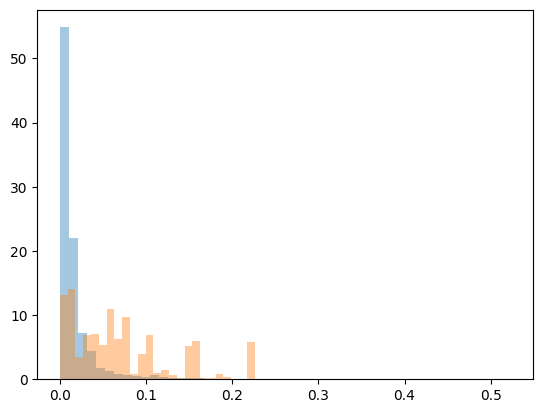

In [36]:
plt.hist(city_df['ffl_density'], weights=1/(city_df['population_2020']+10), bins=50, alpha=0.4, density=True)
plt.hist(shootings_df['ffl_density'], weights=1/(shootings_df['county_population_2020']+10), bins=50, alpha=0.4, density=True)
plt.show()

In [ ]:
shootings_df = mj_shootings[['city', 'state', 'date', 'fatalities', 'injured', 'total_victims', 
                             'latitude', 'longitude', 'x', 'y', 'z', 'ffl_within_25_miles', 'ffl_density']].copy()


In [ ]:

shootings_df = shootings_df.merge(city_df[['city_upper', 'state_upper', 'population', 'density', 'ffl_density']], 
                                  how='left', left_on=['city', 'state'], right_on=['city_upper', 'state_upper'])
shootings_df.rename(columns={'ffl_density_x': 'arm_density'}, inplace=True)
shootings_df['location'] = shootings_df['city'] + ', ' + shootings_df['state']
simulation_df = shootings_df[['location', 'date', 'fatalities', 'injured', 'total_victims', 
                              'population', 'density', 'arm_density', 
                              'latitude', 'longitude', 'x', 'y', 'z']].copy()
simulation_df.rename(columns={'latitude': 'lat', 'longitude': 'lng'}, inplace=True)
city_df['city_state'] = city_df['city_upper'] + ', ' + city_df['state_upper']

In [254]:
historical_pop_df = pd.read_csv(f'{data_dir}/historical_county_populations_v2.csv')
county_data = pd.read_csv(f'{data_dir}/uscounties.csv')
county_data['x'], county_data['y'], county_data['z'] = lat_long_to_spherical_vector(county_data['lat'], county_data['lng'])
county_data = county_data.merge(historical_pop_df, how='left', left_on=['county_fips'], right_on=['cty_fips'])

In [255]:
def find_closest(df1, df2):
    ball_tree = BallTree(df2[['x', 'y', 'z']].values, leaf_size=2)
    neighbors = ball_tree.query(df1[['x', 'y', 'z']].values, k=1)
    return neighbors
neighbor_county_dist, neighbor_county_rows = find_closest(city_df, county_data)

In [ ]:
city_df = pd.concat([city_df.reset_index(drop=True), 
                     county_data.iloc[neighbor_county_rows.flatten()].reset_index(drop=True).rename(columns=lambda x: x + '_county')], axis=1)
city_df['nearest_county_dist'] = neighbor_county_dist
city_df = city_df[city_df['nearest_county_dist'] < 50]
city_df = city_df[city_df['density'] > 50]
city_df = city_df[city_df['population'] > 5000]

In [265]:
synthetic_df = city_df[['city_state', 'population', 'density', 'ffl_within_25_miles', 'ffl_density']].dropna().rename(columns={'city_state': 'location',
                                                                                                                     'ffl_density': 'arm_density',
                                                                                                               'ffl_within_25_miles': 'arm_count'})
synthetic_df = synthetic_df[synthetic_df['population'] > 50000]
synthetic_df = synthetic_df[synthetic_df['density'] > 1000]

In [285]:
city_loc = simulation_df['location'] #pd.concat([simulation_df['location'], synthetic_df['location']])

In [267]:
city_population_data = pd.read_csv(f'{data_dir}1790-2010_MASTER.csv')
city_population_data['state'] = city_population_data['ST'].apply(state_acr.get)
city_population_data['city_state'] = city_population_data['City'].apply(clean_string) + ', ' + city_population_data['state']

In [268]:
known_cities = set(city_population_data['city_state'].dropna())
query_cities = set(city_loc)
print(f'Known cities: {len(known_cities)}, Query cities: {len(query_cities)}', 'found cities:', len(known_cities.intersection(query_cities)))

Known cities: 8874, Query cities: 648 found cities: 615


In [89]:
from gvabm.param_distr import CityParams, EventOutcome
city_data = {c: {'events': []} for c in set(simulation_df['location']).union(synthetic_df['location'])}
for i, row in simulation_df.iterrows():
    c = row.location
    city_data[c]['params'] = CityParams(row.population, row.density, row.arm_density*3.14*25*25, row.arm_density)
    city_data[c]['events'].append(EventOutcome(row.date, row.fatalities, row.injured, row.total_victims))
for i, row in synthetic_df.iterrows():
    c = row.location
    if 'params' in city_data[c]:
        continue
    city_data[c]['params'] = CityParams(row.population, row.density, row.arm_density*3.14*25*25, row.arm_density)

In [274]:
event_pops = [c['params'].population for c in city_data.values() if len(c['events']) > 0]

In [279]:
event_pops = np.array(event_pops)
event_pops = event_pops[~np.isnan(event_pops)]
np.min(event_pops), np.max(event_pops), np.median(event_pops)

(np.float64(550.0), np.float64(8489066.0), np.float64(129897.0))

In [280]:
print((event_pops >= 5000).sum(), (event_pops >= 10000).sum(), (event_pops >= 50000).sum(), (event_pops >= 100000).sum())

107 106 77 65


In [283]:
event_pops.shape

(121,)

In [216]:
import pickle
with open(f'{data_dir}/county_data.pkl', 'wb') as f:
    pickle.dump(city_data, f)

In [217]:
simulation_df

,location,date,fatalities,injured,total_victims,population,density,arm_density,lat,lng,x,y,z
0,"WINDER, GEORGIA",9/4/24,4,9,13,18847.0,505.4,0.121783,33.991700,-83.721800,358.941186,-3262.629357,2213.257406
1,"FORDYCE, ARKANSAS",6/21/24,4,10,14,3320.0,190.6,0.007134,33.818200,-92.417400,-138.727038,-3286.074611,2203.307945
2,"LAS_VEGAS, NEVADA",12/6/23,3,1,4,2256509.0,1771.5,0.141656,36.233300,-115.265400,-1362.910482,-2887.771660,2339.946003
3,"LEWISTON, MAINE",10/25/23,18,13,31,37886.0,428.4,0.041274,44.091500,-70.168100,964.632010,-2674.695102,2754.557793
4,"JACKSONVILLE, FLORIDA",8/26/23,3,0,3,1303156.0,496.9,0.123822,30.332200,-81.674900,494.730003,-3380.881674,1999.244550
...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,"PALM_BAY, FLORIDA",4/23/1987,6,14,20,547659.0,558.0,0.065732,28.033189,-80.642970,568.130173,-3447.841450,1860.568430
147,"EDMOND, OKLAHOMA",8/20/1986,15,6,21,95618.0,437.2,0.143694,35.667201,-97.429370,-415.867028,-3189.198200,2308.282240
148,"SAN_YSIDRO, CALIFORNIA",7/18/1984,22,19,41,NaN,NaN,0.029554,32.552001,-117.043081,-1517.149763,-2972.047430,2130.091104
149,"DALLAS, TEXAS",6/29/1984,6,1,7,5843632.0,1477.2,0.451975,32.925166,-96.838676,-395.676752,-3299.300765,2151.778754


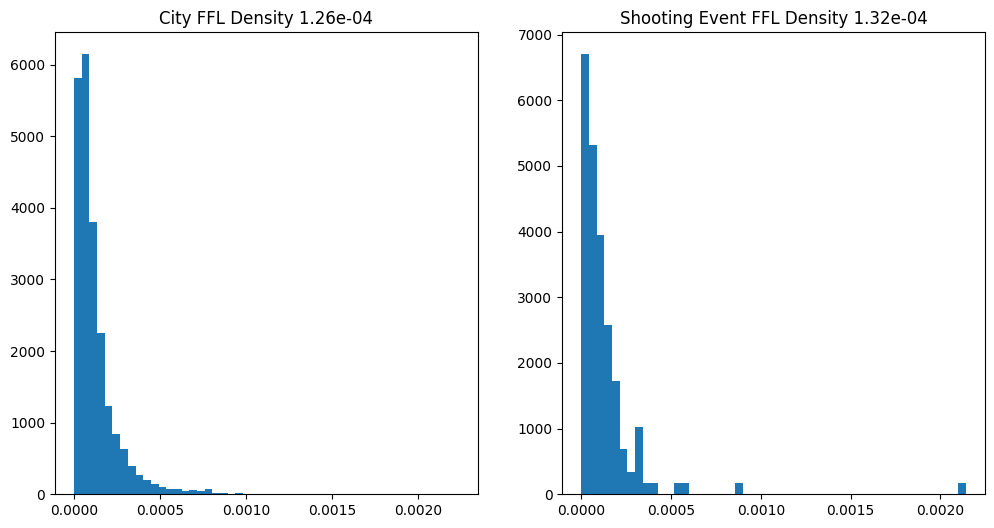

In [131]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

city_density = synthetic_df['arm_density'] / synthetic_df['density']
mj_density = simulation_df['arm_density'] / simulation_df['density']
#normalize histograms
ax[0].hist(city_density, bins=50, density=True)
ax[0].set_title(f'City FFL Density {city_density.mean():.2e}')
ax[1].hist(mj_density, bins=50, density=True)
ax[1].set_title(f'Shooting Event FFL Density {mj_density.mean():.2e}')
plt.show()

In [219]:
import plotly.express as px
import plotly.graph_objects as go

#Plot two plotly figs side by side
fig = px.scatter_geo(mj_shootings, lat='latitude', lon='longitude', 
                     color=np.log1p(100*mj_shootings['ffl_density']),
                     color_continuous_scale='Viridis',
                     title='Mass Shootings in the US, by City (2013-2023)',
                     labels={'color': 'FFL Density (within 25 miles)'},
                     scope='usa',
                     size_max=10,
                     height=600)
fig.update_traces(marker=dict(size=8, opacity=0.8))
# fig.show()

fig = go.Figure(data=go.Scattergeo(
        lon = city_df['lng'],
        lat = city_df['lat'],
        text = city_df['city_upper'] + ', ' + city_df['state_id'],
        mode = 'markers',
        # marker_color = city_df['ffl_density'],
        marker_color = np.log1p(100*city_df['ffl_density']),
        marker = dict(
            size = 3,
            opacity = 0.8,
            colorbar=dict(title=dict(text="FFL Density (within 25 miles)"))
            )
        )
)
fig.update_layout(
        title = 'Licensed Firearm Realtors in the US, by Zip Code',
        geo_scope='usa',
    )
fig.show()

ValueError: cannot reindex on an axis with duplicate labels

In [316]:
city_df['city_ffl_count'] = pd.merge(city_df[['city_upper', 'state_upper']], 
                                     city_arm_counts[['PREMISE_CITY', 'PREMISE_STATE', 'arm_count']], 
                                     left_on=['city_upper', 'state_upper'], right_on=['PREMISE_CITY', 'PREMISE_STATE'], how='left')['arm_count'].fillna(0).values
city_df['city_ffl_density'] = city_df['city_ffl_count'] / city_df['population'] * city_df['density']

In [317]:
city_df.fillna(0, inplace=True)

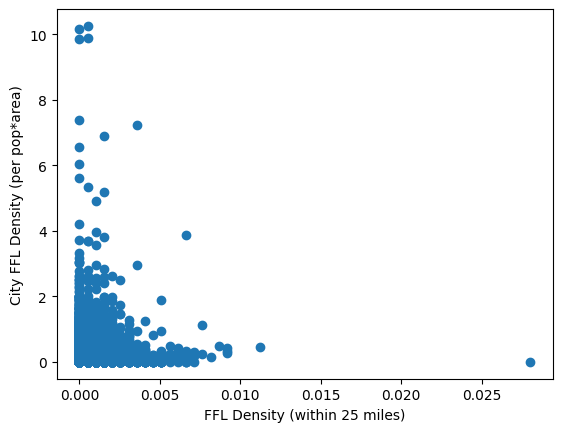

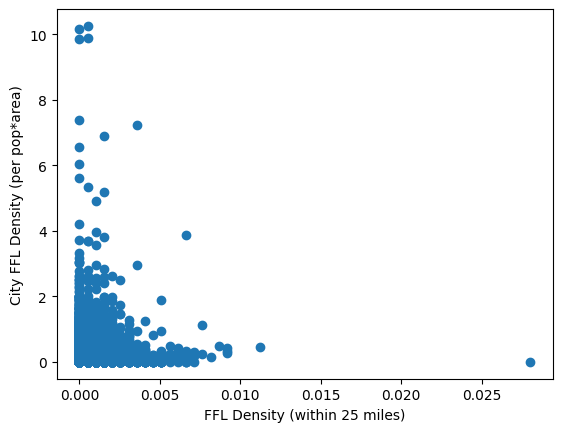

In [318]:
import matplotlib.pyplot as plt
plt.scatter(city_df['ffl_density'], city_df['city_ffl_density'])
plt.xlabel('FFL Density (within 25 miles)')
plt.ylabel('City FFL Density (per pop*area)')
plt.show(0)

In [ ]:

# fig = px.scatter_geo(major_licenses,lat='LAT',lon='LNG', hover_name="LICENSE_NAME")
# fig.update_traces(marker=dict(size=3))
# fig.update_layout(title = 'Licensed Gun Realtors', title_x=0.5)
# fig.show()

fig = go.Figure(data=go.Scattergeo(
        lon = major_licenses['LNG'],
        lat = major_licenses['LAT'],
        text = major_licenses['LICENSE_NAME'],
        mode = 'markers',
        # marker_color = major_licenses['count'],
        marker = dict(
            size = 3,
            opacity = 0.8,
        colorbar=dict(
                title=dict(
                    text="Log(Number of Licensed Realtors)")
                    )
            )
        )
)

fig.update_layout(
        title = 'Licensed Firearm Realtors in the US, by Zip Code',
        geo_scope='usa',
    )
fig.show()

In [262]:
import plotly.express as px
import plotly.graph_objects as go

fig = px.scatter_geo(city_df,lat='lat',lon='lng', hover_name="city_upper")
fig.update_traces(marker=dict(size=3))
fig.update_layout(title = 'Licensed Gun Realtors', title_x=0.5)
fig.show()

fig = go.Figure(data=go.Scattergeo(
        lon = city_df['lng'],
        lat = city_df['lat'],
        text = city_df['city_upper'],
        mode = 'markers',
        # marker_color = city_df['count'],
        marker = dict(
            size = 3,
            opacity = 0.8,
        colorbar=dict(
                title=dict(
                    text="Log(Number of Licensed Realtors)")
                    )
            )
        )
)

fig.update_layout(
        title = 'Cities in the US',
        geo_scope='usa',
    )
fig.show()

In [252]:
print(city_df.columns)
print(ffl_df.columns)
print(zips_loc.columns)
print(mj_shootings.columns)

Index(['city', 'city_ascii', 'state_id', 'state_name', 'county_fips',
       'county_name', 'lat', 'lng', 'population', 'density', 'source',
       'military', 'incorporated', 'timezone', 'ranking', 'zips', 'id',
       'city_upper', 'state_upper'],
      dtype='object')
Index(['LIC_REGN', 'LIC_DIST', 'LIC_CNTY', 'LIC_TYPE', 'LIC_XPRDTE',
       'LIC_SEQN', 'LICENSE_NAME', 'BUSINESS_NAME', 'PREMISE_STREET',
       'PREMISE_CITY', 'PREMISE_STATE', 'PREMISE_ZIP_CODE', 'MAIL_STREET',
       'MAIL_CITY', 'MAIL_STATE', 'MAIL_ZIP_CODE', 'VOICE_PHONE',
       'PREMISE_STATE_ACR'],
      dtype='object')
Index(['ZIP', 'LAT', 'LNG'], dtype='object')
Index(['location', 'summary', 'fatalities', 'injured', 'total_victims',
       'latitude', 'longitude', 'type', 'year', 'state', 'city', 'lat', 'lng'],
      dtype='object')


In [100]:
#reset index of major_licenses
city_loc


,city,city_ascii,state_id,state_name,county_fips,county_name,lat,lng,population,density,source,military,incorporated,timezone,ranking,zips,id
0,New York,NEW YORK,NY,New York,36081,Queens,40.6943,-73.9249,18832416,10943.7,shape,False,True,America/New_York,1,11229 11226 11225 11224 11223 11221 11220 1138...,1840034016
1,Los Angeles,LOS ANGELES,CA,California,6037,Los Angeles,34.1141,-118.4068,11885717,3165.8,shape,False,True,America/Los_Angeles,1,90291 90293 90292 91316 91311 90035 90034 9003...,1840020491
2,Chicago,CHICAGO,IL,Illinois,17031,Cook,41.8375,-87.6866,8489066,4590.3,shape,False,True,America/Chicago,1,60018 60649 60641 60640 60643 60642 60645 6064...,1840000494
3,Miami,MIAMI,FL,Florida,12086,Miami-Dade,25.7840,-80.2101,6113982,4791.1,shape,False,True,America/New_York,1,33128 33129 33125 33126 33127 33149 33144 3314...,1840015149
4,Houston,HOUSTON,TX,Texas,48201,Harris,29.7860,-95.3885,6046392,1386.5,shape,False,True,America/Chicago,1,77069 77068 77061 77060 77063 77062 77065 7706...,1840020925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31249,Mount Wilson,MOUNT WILSON,NV,Nevada,32017,Lincoln,38.2350,-114.4504,0,2.2,shape,False,True,America/Los_Angeles,5,89043,1840039843
31250,Kohatk,KOHATK,AZ,Arizona,4021,Pinal,32.5781,-112.0032,0,77.3,shape,False,False,America/Phoenix,3,85634,1840022983
31251,Ironville,IRONVILLE,PA,Pennsylvania,42013,Blair,40.6586,-78.2155,0,59.2,shape,False,False,America/New_York,3,16686,1840152922
31252,Newkirk,NEWKIRK,NM,New Mexico,35019,Guadalupe,35.0635,-104.2715,0,0.0,shape,False,False,America/Denver,3,88417,1840024978


In [80]:
fallback_loc

,PREMISE_CITY,city,city_ascii,state_id,state_name,county_fips,county_name,lat,lng,population,density,source,military,incorporated,timezone,ranking,zips,id
0,AGUADA,Aguada,AGUADA,PR,Puerto Rico,72003.0,Aguada,18.3803,-67.1884,3182.0,2439.7,shape,False,False,America/Puerto_Rico,2.0,00602,1.630024e+09
1,CABO ROJO,Cabo Rojo,CABO ROJO,PR,Puerto Rico,72023.0,Cabo Rojo,18.0867,-67.1482,9222.0,1511.1,shape,False,False,America/Puerto_Rico,3.0,00623,1.630024e+09
2,ISABELA,Isabela,ISABELA,PR,Puerto Rico,72071.0,Isabela,18.4991,-67.0220,10642.0,1569.4,shape,False,False,America/Puerto_Rico,3.0,00662,1.630024e+09
3,MOCA,Moca,MOCA,PR,Puerto Rico,72099.0,Moca,18.3943,-67.1138,620.0,1576.2,shape,False,False,America/Puerto_Rico,3.0,00676,1.630036e+09
4,QUEBRADILLAS,Quebradillas,QUEBRADILLAS,PR,Puerto Rico,72115.0,Quebradillas,18.4724,-66.9350,6157.0,1247.6,shape,False,False,America/Puerto_Rico,3.0,00678,1.630036e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86021,SITKA,Sitka,SITKA,AK,Alaska,2220.0,Sitka,57.2401,-135.3152,8393.0,1.1,shape,False,True,America/Sitka,3.0,99835,1.840023e+09
86022,SITKA,Sitka,SITKA,AK,Alaska,2220.0,Sitka,57.2401,-135.3152,8393.0,1.1,shape,False,True,America/Sitka,3.0,99835,1.840023e+09
86023,KETCHIKAN,Ketchikan,KETCHIKAN,AK,Alaska,2130.0,Ketchikan Gateway,55.3556,-131.6698,8151.0,824.9,shape,False,True,America/Sitka,3.0,99901,1.840023e+09
86024,KETCHIKAN,Ketchikan,KETCHIKAN,AK,Alaska,2130.0,Ketchikan Gateway,55.3556,-131.6698,8151.0,824.9,shape,False,True,America/Sitka,3.0,99901,1.840023e+09


In [20]:
aggr_zip['ZIP'].isna().sum()

np.int64(585)

In [21]:
zips = pd.read_csv('data/2013_us_zips.csv')
